In [71]:
import torch
from utils.loading_utils import load_model, get_device
from data_loader.dataset import VoxelGridDataset
from matplotlib import pyplot as plt
from os.path import join, basename
import numpy as np
import json
import argparse
from utils.timers import cuda_timers
import time
import shutil
import os
from psf_depth_reconstructor import PSFDepthReconstructor
from options.inference_options import set_depth_inference_options
from data_loader.dataset import UpsampledFramesDataset
from types import SimpleNamespace
from model.unet import *
from types import SimpleNamespace
import torch
from model.model import E2VIDRecurrentPSF  
from model import unet as unet_mod          
from torch.utils.data import DataLoader
from data_loader.dataset import SequenceUpsampledFramesDataset
import matplotlib.image as mpimg
from model.unet import compute_event_frame, event_frames_to_voxel_grid
import torch.nn.functional as F

In [77]:
## Defind Plot Grid Funcion
def plotgrid(stack):
    num_psf = stack.shape[0]  

    ncols = 5  # 원하는대로
    nrows = (num_psf + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

    for i in range(num_psf):
        row, col = divmod(i, ncols)
        ax = axes[row, col]
        ax.imshow(stack[i].detach().numpy(), cmap='gray')
        ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
        ax.axis('off')

    for i in range(num_psf, nrows*ncols):
        row, col = divmod(i, ncols)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

In [2]:
%load_ext autoreload
%autoreload 2

PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/model_best.pth.tar'
BASE_FOLDER = '/home/yl3836/DENSE/valid_upsampled/valid_sequence_00_town06/'
USE_GPU = True

args = SimpleNamespace(
    path_to_model=PATH_TO_MODEL,
    base_folder=BASE_FOLDER,
    use_gpu=USE_GPU,
)

In [3]:
#### Load model
PATH = args.path_to_model
ckpt = torch.load(PATH, map_location='cpu')

#### Same config as used in training
cfg = dict(num_bins=5, skip_type='sum', recurrent_block_type='convlstm',
           num_encoders=3, base_num_channels=32,
           num_residual_blocks=2, use_upsample_conv=True, norm='none', psf_init='random')

#### Top-level model class
model = E2VIDRecurrentPSF(cfg)

######## Loading the weights
model.load_state_dict(ckpt['state_dict'])  

######## Evaluation mode : disable dropout
model.eval()

#### Load optimized psf
net = model.unetrecurrentpsf

Using UpsampleConvLayer (slow, but no checkerboard artefacts)


In [4]:
#### CPU safe collate copied from train.py 

def _to_device(x, device):
    if isinstance(x, torch.Tensor):
        return x.to(device, non_blocking=True)
    if isinstance(x, dict):
        return {k: _to_device(v, device) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(_to_device(v, device) for v in x)
    return x

def collate_keep_sequence(batch, device):
    # batch: [N] where each item is a sequence [L] of dicts
    return _to_device(batch, device)

In [5]:
device = 'cpu' 

unet_mod.gpu = device   # used by UNetRecurrentPSF to move tensors
model.to(device).eval() 

#### load dataset
ds = SequenceUpsampledFramesDataset(
    base_folder=BASE_FOLDER,
    event_folder='',
    depth_folder='imgs',
    frame_folder='frames',
    sequence_length=20, step_size=1, normalize=True
)

loader = DataLoader(
    ds, batch_size=1, shuffle=False,
    collate_fn=lambda b: collate_keep_sequence(b, device),
    num_workers=0, pin_memory=False
)

batch = next(iter(loader))                

##### Forming sequence, copied from lstm.py
sequence = list(map(list, zip(*batch)))   
cur_input   = sequence[0]                 
prev_states = None

#### This is the forward model of top-level model
with torch.no_grad():
    voxel, frame, pred, states, timing = model.unetrecurrentpsf(cur_input, prev_states, downsample=False, measure_time = True)
print(voxel.shape, frame.shape, pred.shape)

torch.Size([1, 5, 260, 346]) torch.Size([1, 1, 260, 346]) torch.Size([1, 1, 260, 346])


#### Load depth n Check

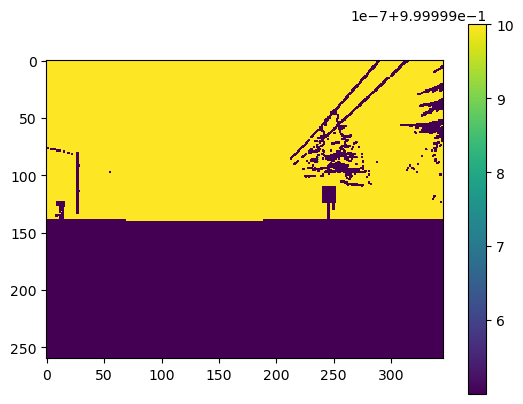

In [6]:
# GT depth map that converted into log scale
plt.imshow(frame.squeeze().squeeze(), vmin=0.9999995, vmax=1)  # GT depth map
plt.colorbar()

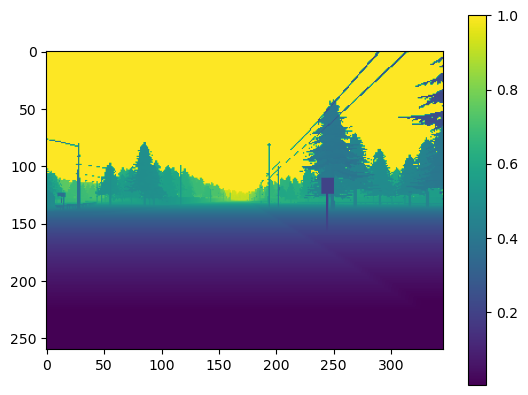

In [7]:
#### To compare : Ground truth depth image

path = "/home/yl3836/DENSE/valid_upsampled/valid_sequence_00_town06/imgs/00000000.png"
img = mpimg.imread(path)                
plt.imshow(img)             
plt.colorbar()


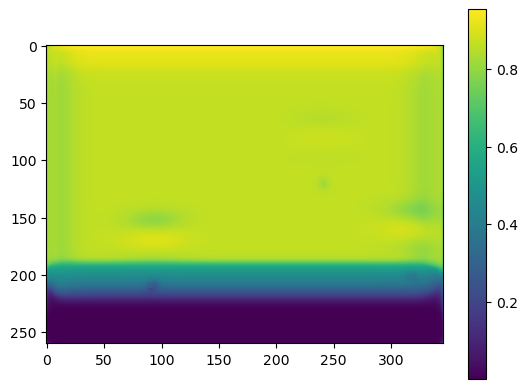

In [8]:
#### Prediction of the network in log scale
plt.imshow(pred.squeeze().squeeze())  
plt.colorbar()

Where is the sequence formed?

dataset.py : SequenceUpsampledFrameDataset

self.dataset = UpsampledFramesDataset

A. Clip into maximum depth = 100
- check is it 100? (Intensity in the dataset is 1 but cant see how its loading)

B. Normalize and frame = 1.0 + np.log(frame + eps) / reg_factor
- why reg_factor=3.70378 ?

Code : frame = np.clip(frame, 0.0, self.clip_distance)


In [9]:
    #  # Normalize
    #     frame = frame / np.amax(frame[~np.isnan(frame)])
    #     div = abs(np.min(np.log(frame+self.eps)))

    #     # Inverse depth
    #     if self.inverse:
    #         frame = 1.0 / frame
    #         frame = frame / np.amax(frame[~np.isnan(frame)])

    #     # #Convert to log depth
    #     eps   = 1e-6
    #     frame = 1.0 + np.log(frame + eps) / reg_factor
    #     # # Clip between 0 and 1.0
    #     frame = frame.clip(0, 1.0)

    #     if len(frame.shape) == 2:  # [H x W] grayscale image -> [H x W x 1]
    #         frame = np.expand_dims(frame, -1)

    #     frame = np.moveaxis(frame, -1, 0)  # H x W x C -> C x H x W
    #     frame = torch.from_numpy(frame) #numpy to tensor

## Load data from one sample

In [10]:
#### Choosing one sample
l, n = 0, 0
item = sequence[l][n]         

frames = item['frames'].to(device)          # [T, 1, H, W], already normalized [0,1] by the dataset
stamps = item['stamps'].to(device).float()  # [T] timestamps
frame = item['frame'].to(device)    # depth in log scale
md     = item['metric_depth'].to(device) 

print(frames.shape, frame.shape, md.shape, stamps.shape)

torch.Size([9, 1, 260, 346]) torch.Size([1, 260, 346]) torch.Size([1, 260, 346]) torch.Size([9])


### Model Probing - Original Forward Code

In [11]:
self = model.unetrecurrentpsf.psf_layer

#### Copied from UnetRecurrentPSF forward
depth = md
depth = depth / 255.0
depth = depth * (15 - 2) + 2
depth_bins = depth

image = frames

In [12]:
#### Copied from UnetRecurrentPSF forward
image = image.squeeze(0)
T, _, H, W = image.shape
D = self.num_depths
k = self.psf_size

psfs = f.softplus(self.psfs)

scaled = psfs
psfs  = scaled / scaled.sum(dim=(-2, -1), keepdim=True) * (self.psf_size ** 2)
psfs = torch.flip(psfs, (-2,-1))


In [13]:
image = image.squeeze(0)
T, _, H, W = image.shape
D = self.num_depths
k = self.psf_size

psfs = f.softplus(self.psfs) #self.psfs : parameterized psfs after initialization

scaled = psfs
psfs  = scaled / scaled.sum(dim=(-2, -1), keepdim=True) * (self.psf_size ** 2)
psfs = torch.flip(psfs, (-2,-1))

filtered = f.conv2d(image, psfs, padding=self.psf_size // 2)


boundaries = self.higher[:-1]  
depth_idx = torch.bucketize(depth_bins.squeeze(0), boundaries)  # [H,W], 0..D-1
depth_idx_plus = torch.clamp(depth_idx + 1, max=D-1) 


w = (depth_bins.squeeze(0) - self.lower[depth_idx]) / \
    (self.higher[depth_idx] - self.lower[depth_idx]+ 1e-8) 
w = w.expand(T, 1, H, W)

idx_e      = depth_idx     .expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
idx_e_plus = depth_idx_plus.expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
out_d        = torch.gather(filtered, 1, idx_e)                  # PSF_d
out_d_plus   = torch.gather(filtered, 1, idx_e_plus)              # PSF_{d+1}

                        
output = (1 - w) * out_d + w * out_d_plus

(9, 15, 261, 347)


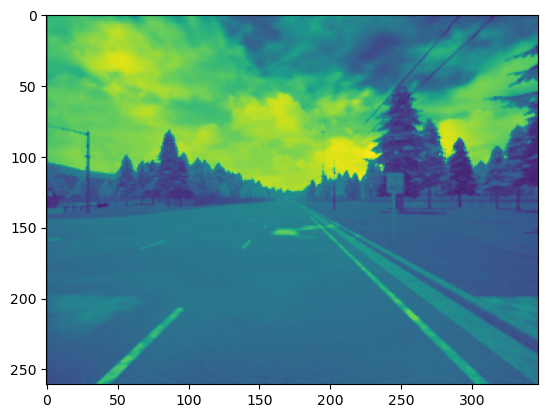

In [14]:
print(filtered.detach().numpy().shape)
plt.imshow(filtered.detach().numpy()[0][0])

### SANITY CHECK : Swipe order

In [15]:
# Setting up self inorder to run forward in DepthDependentPSFLayer class
self = model.unetrecurrentpsf.psf_layer

# setting up inputs for UnetRecurrentPSF -> DepthDependentPSFLayer
image = frames

In [16]:
#### Copied from DepthDependentPSFLayer forward
image = image.squeeze(0)
T, _, H, W = image.shape
D = self.num_depths
k = self.psf_size

psfs = f.softplus(self.psfs)

scaled = psfs
psfs  = scaled / scaled.sum(dim=(-2, -1), keepdim=True) * (self.psf_size ** 2)
psfs = torch.flip(psfs, (-2,-1))

#### Visualizing psfs

(15, 1, 20, 20)


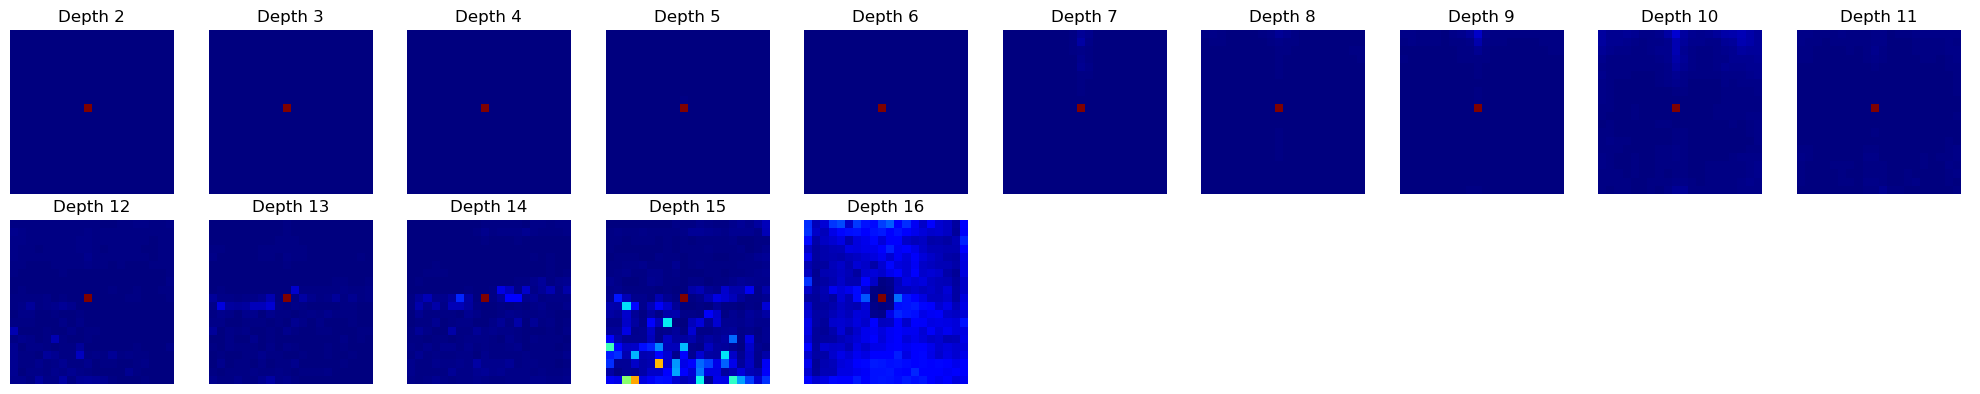

In [17]:
#### Just before convolving
print(psfs.detach().numpy().shape)

psf_stack = psfs.squeeze()

num_psf = psf_stack.shape[0]  
ncols = 10  # 원하는대로
nrows = (num_psf + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

for i in range(num_psf):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    ax.imshow(psf_stack[i].detach().numpy(), cmap='jet')
    ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
    ax.axis('off')

for i in range(num_psf, nrows*ncols):
    row, col = divmod(i, ncols)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [18]:
#### Before, there was a convolution inside the DepthDependentPSFLayer
#### Also weighted depth was applied

#### In the new experiment, I'll comment out all these and assume getting only psfs as an output

################## ORIGINAL CODE THAT SHOULD BE COMMENTED OUT ##################
# filtered = f.conv2d(image, psfs, padding=self.psf_size // 2)


# boundaries = self.higher[:-1]  
# depth_idx = torch.bucketize(depth_bins.squeeze(0), boundaries)  # [H,W], 0..D-1
# depth_idx_plus = torch.clamp(depth_idx + 1, max=D-1) 


# w = (depth_bins.squeeze(0) - self.lower[depth_idx]) / \
#     (self.higher[depth_idx] - self.lower[depth_idx]+ 1e-8) 
# w = w.expand(T, 1, H, W)

# idx_e      = depth_idx     .expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
# idx_e_plus = depth_idx_plus.expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
# out_d        = torch.gather(filtered, 1, idx_e)                  # PSF_d
# out_d_plus   = torch.gather(filtered, 1, idx_e_plus)              # PSF_{d+1}

                        
# output = (1 - w) * out_d + w * out_d_plus
###################################################################################

In [19]:
# NOW I HAVE psfs from DepthDependentPSFLayer as an output:
print(psfs.detach().numpy().shape)
# And self was defined as : self = model.unetrecurrentpsf.psf_layer
# In UnetRecurrentPSF : self.psf_layer = DepthDependentPSFLayer(min_depth=2, max_depth=16, psf_init='delta', psf_size=20)

################################# ** IMPORTANT ** ##################################
# SO IDEALLY IF I IMPLEMENT, In UnetRecurrentPSF : self.psf_layer =  psfs
# WONT NEED depth_bin AS AN INPUT ANYMORE
###################################################################################

# Now I will start applying depth mask, and then convolve it.

(15, 1, 20, 20)


In [20]:
#### Copied from UnetRecurrentPSF forward
depth = md
depth = depth / 255.0
depth = depth * (15 - 2) + 2
depth_bins = depth

min_depth = 2.0
max_depth = 16.0

In [21]:
lower = torch.arange(min_depth, max_depth+1)
higher = lower + 1

print(lower)
print(higher)

lower = lower.unsqueeze(-1).unsqueeze(-1) # Shape [1,1,15] for broadcast
higher = higher.unsqueeze(-1).unsqueeze(-1) # Shape [1,1,15] for broadcast
print(lower.shape)
print(depth_bins.shape)

tensor([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15.,
        16.])
tensor([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
        17.])
torch.Size([15, 1, 1])
torch.Size([1, 260, 346])


In [51]:
# Creating One-Hot mask layers
mask = ((depth_bins >= lower) & (depth_bins < higher)).float()  
print(mask.shape)
print(mask[0])

torch.Size([15, 260, 346])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


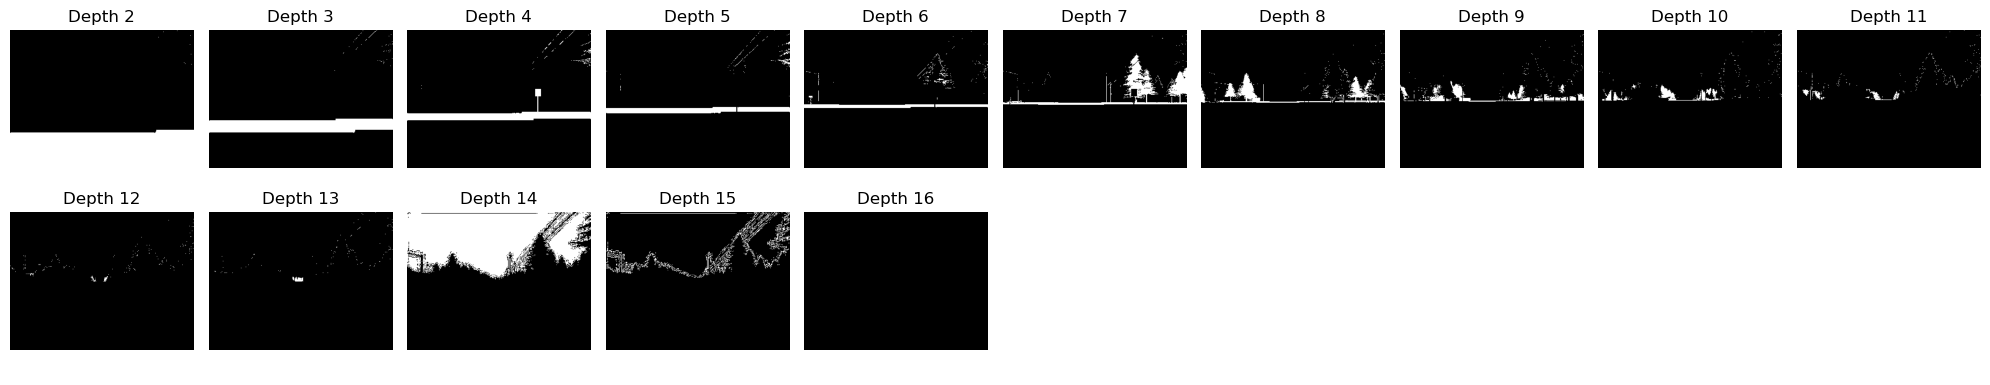

In [64]:
plotgrid(mask)

In [66]:
print(f"Frames shape: {frames.shape}")
masked_frames = mask.unsqueeze(0) * frames
print(masked_frames.shape)

Frames shape: torch.Size([9, 1, 260, 346])
torch.Size([9, 15, 260, 346])


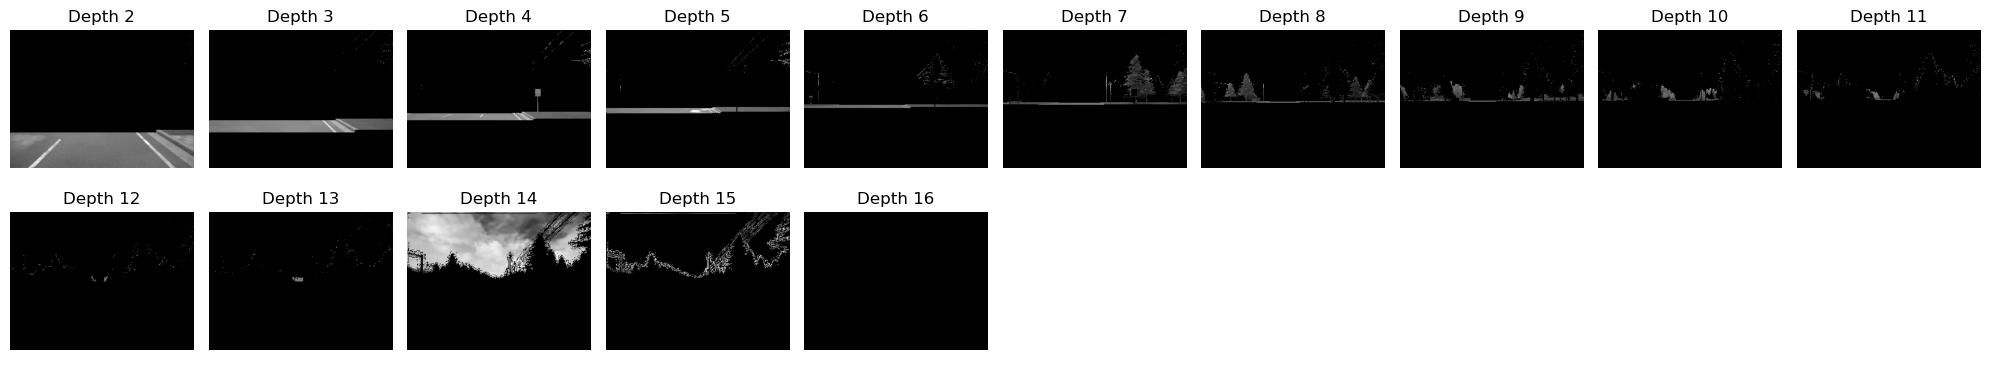

In [67]:
plotgrid(masked_frames[0])

In [ ]:
#### Copied from previous code, just to help

# print(image.shape) # torch.Size([9, 1, 260, 346])
# print(psfs.shape) # torch.Size([15, 1, 20, 20])
# filtered = f.conv2d(image, psfs, padding=self.psf_size // 2)
# # (9, 15, 261, 347)


In [69]:
print(masked_frames.shape) 
print(psfs.shape)

torch.Size([9, 15, 260, 346])
torch.Size([15, 1, 20, 20])


In [74]:
# Option A (PyTorch with padding="same"):
C = masked_frames.shape[1]
out = F.conv2d(masked_frames, psfs, padding="same", groups=C)
print(out.shape)

torch.Size([9, 15, 260, 346])


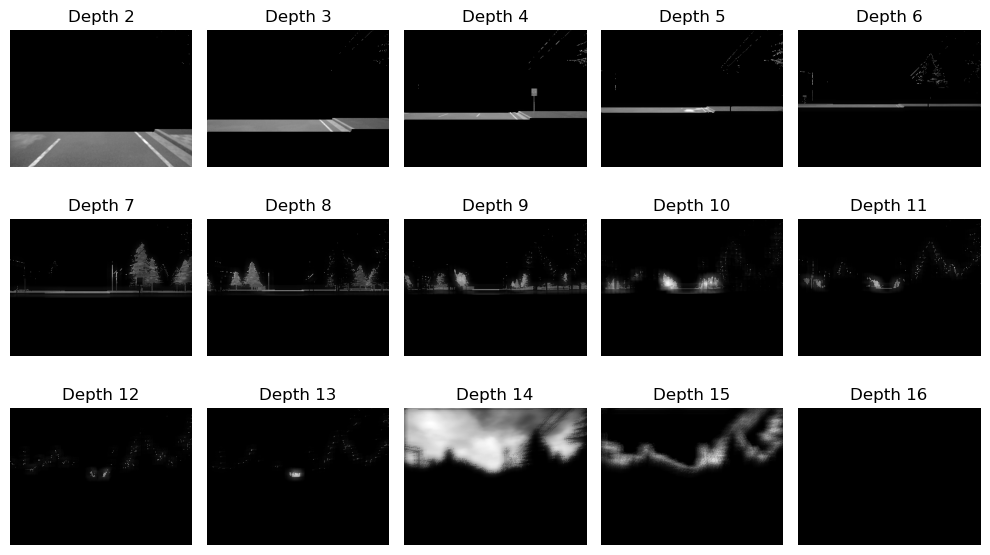

In [78]:
plotgrid(out[0])

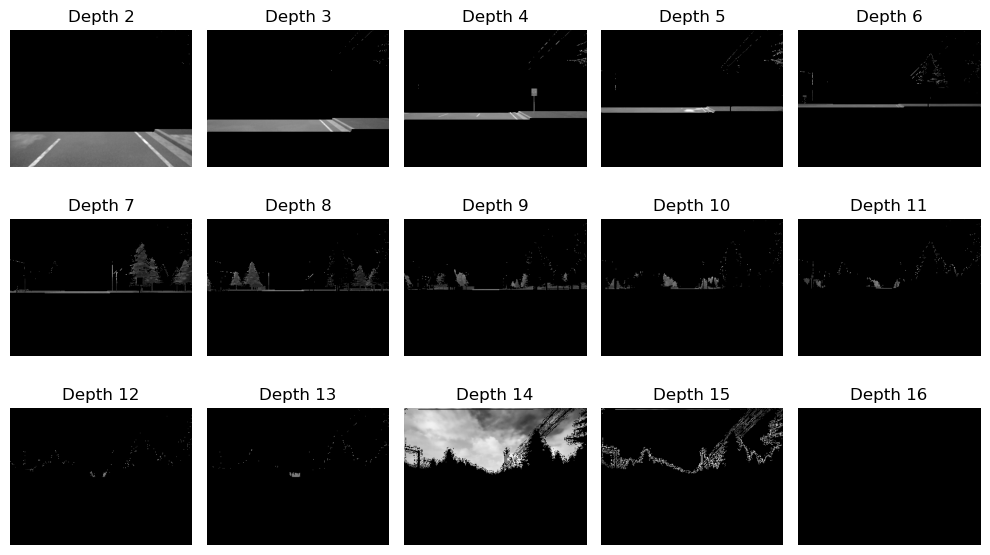

In [79]:
plotgrid(masked_frames[0])

In [24]:

#### Copied from UnetRecurrentPSF forward
depth = md
depth = depth / 255.0
depth = depth * (15 - 2) + 2
depth_bins = depth

min_depth = 2.0
max_depth = 16.0

print(depth_bins)
mask = ((depth_bins >= min_depth) & (depth_bins < max_depth)).float()  
print(mask)

#     convolved_frames = self.psf_layer(cur_input[i]['frames'], depth_bins)

tensor([[[14.9490, 14.9490, 14.9490,  ..., 15.0000, 14.8980, 14.9490],
         [14.9490, 14.8980, 15.0000,  ..., 15.0000, 15.0000, 15.0000],
         [14.9490, 15.0000, 15.0000,  ..., 14.9490, 14.8980, 15.0000],
         ...,
         [ 2.0000,  2.0000,  2.0000,  ...,  2.0510,  2.0510,  2.0000],
         [ 2.0000,  2.0510,  2.0510,  ...,  2.0510,  2.0510,  2.0510],
         [ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000]]])
tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])


In [ ]:

def apply_depth_mask(frames, depth_bins, lo, hi):
    """
    frames:     [T,1,H,W]  grayscale frame sequence (already on your device)
    depth_bins: [1,H,W]    metric depth in meters for this timestep (e.g. 2..16)
    lo, hi:     floats     depth range to KEEP (lo <= depth < hi)

    returns:    [T,1,H,W]  frames masked by the depth range
    """
    # binary mask in [0,1]
    mask = ((depth_bins >= lo) & (depth_bins < hi)).float()          # [1,H,W]
    # expand across time/channel to match frames
    mask = mask.expand(frames.shape[0], 1, frames.shape[-2], frames.shape[-1])
    return frames * mask                                              # [T,1,H,W]

# example:
# frames: [T,1,H,W], depth_bins: [1,H,W] (your screenshot shows 2..~16 m)
masked_frames = apply_depth_mask(frames, depth_bins, lo=8.0, hi=12.0)
print(masked_frames.shape)  # -> same as frames

In [ ]:
# In UnetRecurrentPSF
# self.psf_layer = DepthDependentPSFLayer(min_depth=2, max_depth=16, psf_init='delta', psf_size=20)

In [21]:
print(psfs.detach().numpy().shape)

(15, 1, 20, 20)


In [68]:
image = image.squeeze(0)
T, _, H, W = image.shape
D = self.num_depths
k = self.psf_size

psfs = f.softplus(self.psfs) #self.psfs : parameterized psfs after initialization

scaled = psfs
psfs  = scaled / scaled.sum(dim=(-2, -1), keepdim=True) * (self.psf_size ** 2)
psfs = torch.flip(psfs, (-2,-1))

print(image.shape)
print(psfs.shape)
filtered = f.conv2d(image, psfs, padding=self.psf_size // 2)


boundaries = self.higher[:-1]  
depth_idx = torch.bucketize(depth_bins.squeeze(0), boundaries)  # [H,W], 0..D-1
depth_idx_plus = torch.clamp(depth_idx + 1, max=D-1) 


w = (depth_bins.squeeze(0) - self.lower[depth_idx]) / \
    (self.higher[depth_idx] - self.lower[depth_idx]+ 1e-8) 
w = w.expand(T, 1, H, W)

idx_e      = depth_idx     .expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
idx_e_plus = depth_idx_plus.expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
out_d        = torch.gather(filtered, 1, idx_e)                  # PSF_d
out_d_plus   = torch.gather(filtered, 1, idx_e_plus)              # PSF_{d+1}

                        
output = (1 - w) * out_d + w * out_d_plus

torch.Size([9, 1, 260, 346])
torch.Size([15, 1, 20, 20])


(9, 15, 261, 347)


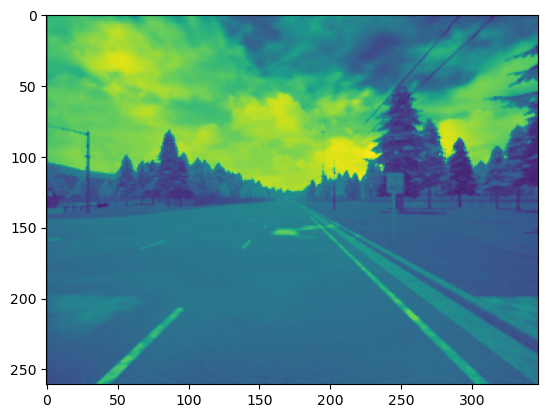

In [73]:
print(filtered.detach().numpy().shape)
plt.imshow(filtered.detach().numpy()[0][0])

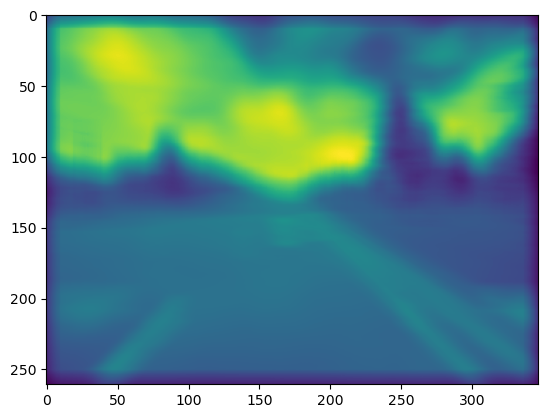

In [75]:
plt.imshow(filtered.detach().numpy()[0][14])

In [ ]:
def forward(self, image, depth_bins):
        
        """
        Applies depth-dependent psfs to sequence of frames.

        Parameters:
            image: sequence_length x 1 x height x width tensor containing sequence of frames
            depth_bins: 1 x height x width tensor containing depth map rounded to nearest integer
        """

        image = image.squeeze(0)
        T, _, H, W = image.shape
        D = self.num_depths
        k = self.psf_size

        psfs = f.softplus(self.psfs)
        
        scaled = psfs
        psfs  = scaled / scaled.sum(dim=(-2, -1), keepdim=True) * (self.psf_size ** 2)
        psfs = torch.flip(psfs, (-2,-1))

        filtered = f.conv2d(image, psfs, padding=self.psf_size // 2)


        boundaries = self.higher[:-1]  
        depth_idx = torch.bucketize(depth_bins.squeeze(0), boundaries)  # [H,W], 0..D-1
        depth_idx_plus = torch.clamp(depth_idx + 1, max=D-1) 

      
        w = (depth_bins.squeeze(0) - self.lower[depth_idx]) / \
            (self.higher[depth_idx] - self.lower[depth_idx]+ 1e-8) 
        w = w.expand(T, 1, H, W)
  
        idx_e      = depth_idx     .expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
        idx_e_plus = depth_idx_plus.expand(T, H, W).unsqueeze(1)               # [T,1,H,W]
        out_d        = torch.gather(filtered, 1, idx_e)                  # PSF_d
        out_d_plus   = torch.gather(filtered, 1, idx_e_plus)              # PSF_{d+1}

                               
        output = (1 - w) * out_d + w * out_d_plus


        return output

torch.Size([9, 1, 260, 346])


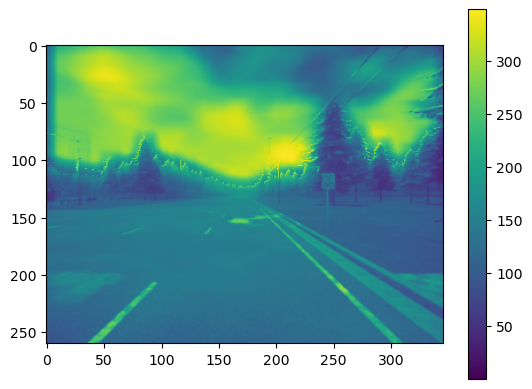

In [65]:
#### Returns DepthDependentPSFLayer, includes convolution
psf = model.unetrecurrentpsf.psf_layer


### Calculate depth, copied from train.py
depth = md
depth = depth / 255.0
depth = depth * (15 - 2) + 2
depth_bins = depth

convolved_frames = psf(frames, depth_bins)
print(convolved_frames.size())
plt.imshow(convolved_frames.squeeze().detach().numpy()[0])
plt.colorbar()

torch.Size([8, 1, 260, 346])


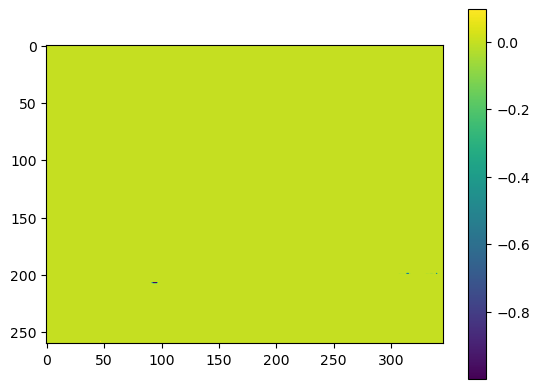

In [48]:
epsilon = 1e-6
log_frames = torch.log(convolved_frames + epsilon)
diffs = log_frames[1:] - log_frames[:-1] 

event_frames = compute_event_frame(diffs)  
print(event_frames.size())
plt.imshow(event_frames.squeeze().detach().numpy()[0])
plt.colorbar()

In [61]:
with torch.no_grad():
    psfs = torch.nn.functional.softplus(model.unetrecurrentpsf.psf_layer.psfs)
    psfs = psfs / psfs.sum(dim=(-2, -1), keepdim=True)  # normalize each kernel
print(psfs.shape) 


torch.Size([15, 1, 20, 20])


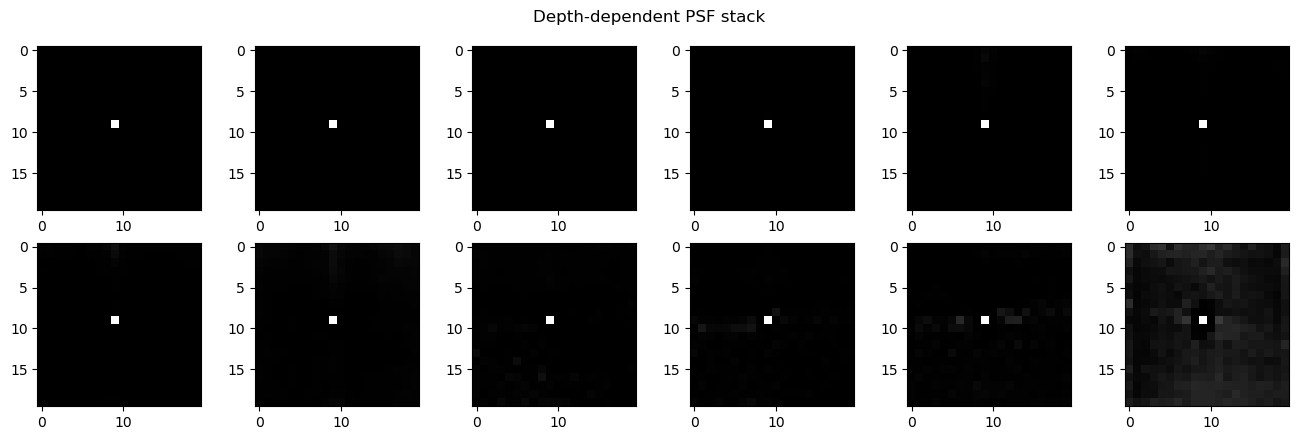

In [ ]:

with torch.no_grad():
    psfs = torch.nn.functional.softplus(psf.psfs)
    psfs = psfs / psfs.sum(dim=(-2, -1), keepdim=True)
    vis  = torch.flip(psfs, dims=[-2, -1])

D = vis.shape[0]
# pick up to 12 roughly-even depths
n_show = min(12, D)
idxs = torch.linspace(0, D-1, steps=n_show).long().tolist()

cols = 6
rows = math.ceil(n_show/cols)
fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
axes = np.array(axes).reshape(rows, cols)

for ax, d in zip(axes.flat, idxs):
    img = vis[d,0].cpu().numpy()
    ax.imshow(img, cmap='gray')
    # ax.set_title(f"{psf.lower[d].item():.1f}-{psf.higher[d].item():.1f} m", fontsize=8)


# turn off any empty slots
for ax in axes.flat[len(idxs):]:
    ax.axis('off')

fig.suptitle("Depth-dependent PSF stack", y=0.98)
plt.tight_layout(); plt.show()


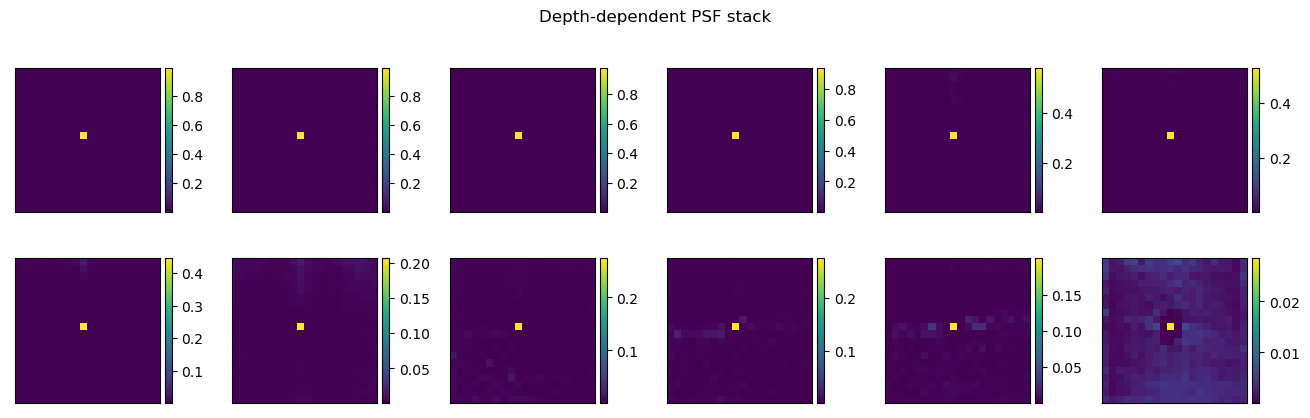

In [62]:
import math, numpy as np, torch
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

with torch.inference_mode():
    psfs = torch.nn.functional.softplus(psf.psfs)
    psfs = psfs / psfs.sum(dim=(-2, -1), keepdim=True)
    vis  = torch.flip(psfs, dims=(-2, -1))   # (D, [C,] H, W)

D = vis.shape[0]
n_show = min(12, D)
idxs = np.unique(np.linspace(0, D - 1, num=n_show, dtype=int)).tolist()
n_show = len(idxs)

cols = 6
rows = math.ceil(n_show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows), squeeze=False)

# shared normalization so colorbars are comparable
# vmin, vmax = 0.0, float(vis.max().cpu())
#norm = colors.Normalize(vmin=vmin)

for ax, d in zip(axes.flat, idxs):
    # handle (D,H,W) or (D,C,H,W)
    img = (vis[d] if vis.ndim == 3 else vis[d, 0]).detach().cpu().numpy()
    im = ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])

    # append a small axis on the right for this subplot's colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)

# turn off any empty slots
for ax in axes.flat[n_show:]:
    ax.axis('off')

fig.suptitle("Depth-dependent PSF stack", y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
##### Load Model
%load_ext autoreload
%autoreload 2

PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/model_best.pth.tar'
BASE_FOLDER = '/home/yl3836/DENSE/valid_upsampled/valid_sequence_00_town06/'
USE_GPU = True

args = SimpleNamespace(
    path_to_model=PATH_TO_MODEL,
    base_folder=BASE_FOLDER,
    use_gpu=USE_GPU,
)

ckpt = torch.load(PATH_TO_MODEL, map_location='cpu')

num_bins = 5  
net = UNetRecurrentPSF(num_input_channels=num_bins, num_output_channels=1,
                       skip_type='sum', recurrent_block_type='convlstm',
                       num_encoders=3, base_num_channels=32,
                       num_residual_blocks=2, use_upsample_conv=True)

Using UpsampleConvLayer (slow, but no checkerboard artefacts)


In [4]:
##### Load PSF Layers
print(net.psf_layer.psfs.shape)

torch.Size([15, 1, 20, 20])


In [5]:
##### Check Model 
# print(net)
for name, mod in net.named_children():
    print(name, '->', mod.__class__.__name__)

list(net._modules.keys()) 

unet_recurrent -> UNetRecurrent
psf_layer -> DepthDependentPSFLayer


['unet_recurrent', 'psf_layer']

In [6]:
net.forward(frames[0])

NameError: name 'frames' is not defined

In [33]:
def plot_psf(path, epoch):

    path = f"{path}/epoch_{epoch:03d}.pt"
    raw = torch.load(path)                 # [D,1,k,k]  (raw parameter; can be negative)
    k = raw.shape[-1]

    vmin, vmax = 0,3.0

    used = torch.nn.functional.softplus(raw)                 # ≥ 0
    used = used / used.sum(dim=(-2, -1), keepdim=True)       # 정규화
    used = used * (k ** 2)                                   # forward와 동일 스케일
    used = torch.flip(used, dims=[-2, -1])                   # conv2d용 flip                # 비음수 확인

    # (선택) ‘물리적 PSF 모양’을 보고 싶다면 flip을 빼고 시각화
    physical = torch.nn.functional.softplus(raw)
    physical = physical / physical.sum(dim=(-2, -1), keepdim=True)
    # physical 은 conv2d flip 전의 모양

    # 플롯(예: used 보여주기)
    psf_stack = used.squeeze(1)  # [D,k,k]
    D = psf_stack.shape[0]
    ncols = 10
    nrows = math.ceil(D / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows), squeeze=False)

    for i in range(D):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        im = ax.imshow(psf_stack[i].cpu().numpy(), cmap='jet')
        fig.colorbar(im, ax=ax)
        ax.set_title(f"Depth {i+2}")  # min_depth=2 기준
        ax.axis('off')

    for i in range(D, nrows*ncols):
        r, c = divmod(i, ncols)
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

In [2]:
device = torch.device(f"cuda:0")

In [15]:
%load_ext autoreload
%autoreload 2

PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/model_best.pth.tar'
BASE_FOLDER = '/home/yl3836/DENSE/valid_upsampled/valid_sequence_00_town06/'
USE_GPU = True

args = SimpleNamespace(
    path_to_model=PATH_TO_MODEL,
    base_folder=BASE_FOLDER,
    use_gpu=USE_GPU,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
PATH_TO_MODEL = args.path_to_model 
ckpt = torch.load(PATH_TO_MODEL, map_location='cpu')

num_bins = 5  
net = UNetRecurrentPSF(num_input_channels=num_bins, num_output_channels=1,
                       skip_type='sum', recurrent_block_type='convlstm',
                       num_encoders=3, base_num_channels=32,
                       num_residual_blocks=2, use_upsample_conv=True)

# 가중치 주입
state = ckpt['state_dict'] if isinstance(ckpt, dict) and 'state_dict' in ckpt else ckpt
missing, unexpected = net.load_state_dict(state, strict=False)
net.eval()
print("missing:", missing, "unexpected:", unexpected)


Using UpsampleConvLayer (slow, but no checkerboard artefacts)
missing: ['unet_recurrent.head.conv2d.weight', 'unet_recurrent.head.conv2d.bias', 'unet_recurrent.encoders.0.conv.conv2d.weight', 'unet_recurrent.encoders.0.conv.conv2d.bias', 'unet_recurrent.encoders.0.recurrent_block.Gates.weight', 'unet_recurrent.encoders.0.recurrent_block.Gates.bias', 'unet_recurrent.encoders.1.conv.conv2d.weight', 'unet_recurrent.encoders.1.conv.conv2d.bias', 'unet_recurrent.encoders.1.recurrent_block.Gates.weight', 'unet_recurrent.encoders.1.recurrent_block.Gates.bias', 'unet_recurrent.encoders.2.conv.conv2d.weight', 'unet_recurrent.encoders.2.conv.conv2d.bias', 'unet_recurrent.encoders.2.recurrent_block.Gates.weight', 'unet_recurrent.encoders.2.recurrent_block.Gates.bias', 'unet_recurrent.resblocks.0.conv1.weight', 'unet_recurrent.resblocks.0.conv1.bias', 'unet_recurrent.resblocks.0.conv2.weight', 'unet_recurrent.resblocks.0.conv2.bias', 'unet_recurrent.resblocks.1.conv1.weight', 'unet_recurrent.resbl

In [69]:
print(net.psf_layer.psfs.shape)

torch.Size([15, 1, 20, 20])


In [ ]:
from data_loader.dataset import SequenceUpsampledFramesDataset

BASE = args.base_folder
ds = SequenceUpsampledFramesDataset(base_folder=BASE,
                            depth_folder='imgs',   # 네 폴더명에 맞춰
                            frame_folder='frames',
                            event_folder='')
p

sample = ds[0]
print(len(sample))
frames = sample['frames']          # [T, 1, H, W]  (시퀀스 그레이스케일 프레임)
metric_depth = sample['metric_depth']  # [1, H, W]  (로그변환 전 원시 깊이)
stamps = sample['stamps'].float()      # [T]


2


TypeError: list indices must be integers or slices, not str

In [15]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as f
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import torchvision.utils as vutils
from torchvision import transforms
grayscale = transforms.Grayscale()


# Load Data
# Depths
depth_dir = "/home/yl3836/DENSE/valid/valid_sequence_00_town06/depth/frames"
depth_files = sorted([f for f in os.listdir(depth_dir) if f.endswith(".png")])
depths = []
for i in range(5):
    path = os.path.join(depth_dir, depth_files[i])
    depth_temp = TF.to_tensor(Image.open(path))
    depths.append(depth_temp)
depths = torch.stack(depths)
print(f"depths shape : ",depths.shape)

# frames
frame_dir = "/home/yl3836/DENSE/valid/valid_sequence_00_town06/rgb/frames"
frame_files = sorted([f for f in os.listdir(frame_dir) if f.endswith(".png")])
frames = []
for i in range(5):
    path = os.path.join(frame_dir, frame_files[i])
    frame_temp = TF.to_tensor(Image.open(path))
    frame_temp = grayscale(frame_temp)
    frames.append(frame_temp)
frames = torch.stack(frames)
print(f"frames shape : ",frames.shape)   


depths shape :  torch.Size([5, 1, 260, 346])
frames shape :  torch.Size([5, 1, 260, 346])


In [31]:
# Setting up Depth
depth = (depths - depths.min()) / (depths.max() - depths.min())
depth = depth * (16 - 2) + 2
depth_bins = torch.round(depth)
print(depth_bins.shape)

torch.Size([5, 1, 260, 346])


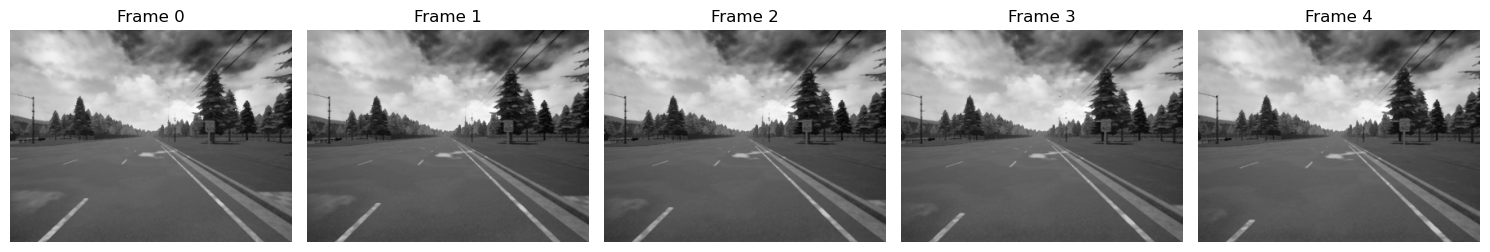

In [35]:
plt.figure(figsize=(15, 3))
for i, img in enumerate(frames):
    plt.subplot(1, 5, i+1)

    img_show = img.squeeze(0)  # grayscale
    plt.imshow(img_show, cmap = "gray")
  
    plt.title(f"Frame {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

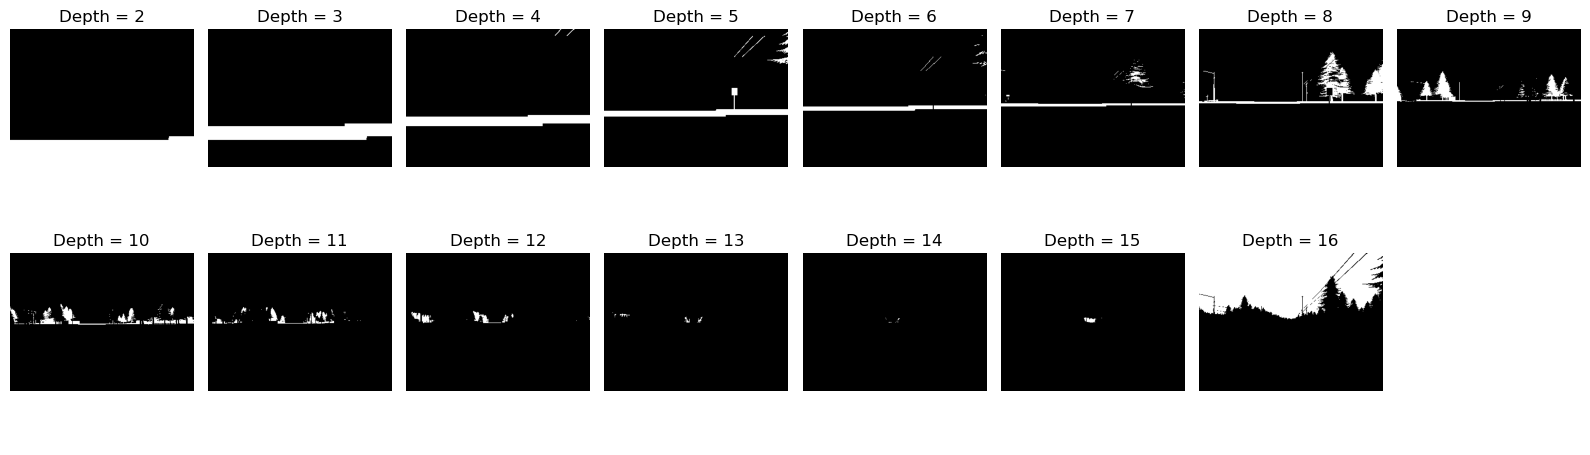

In [ ]:
##### Depth Layer
output = torch.zeros_like(depths[0])
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(16, 5))  # 5x8 = 40개까지 표시
axes = axes.flatten()

idx = 0
for d in range(2, 17):
    if idx >= len(axes):
        break  # 그리드 넘지 않게

    mask = (depth_bins[0] == d).float()
    if mask.sum() == 0:
        continue
    #print(mask.shape)
    ax = axes[idx]
    ax.imshow(mask.squeeze(), cmap='gray')
    ax.set_title(f"Depth = {d}")
    ax.axis('off')
    idx += 1
    
for i in range(idx, len(axes)):
    axes[i].axis('off')

plt.tight_layout()

In [36]:
print(frames[0].shape)

torch.Size([1, 260, 346])


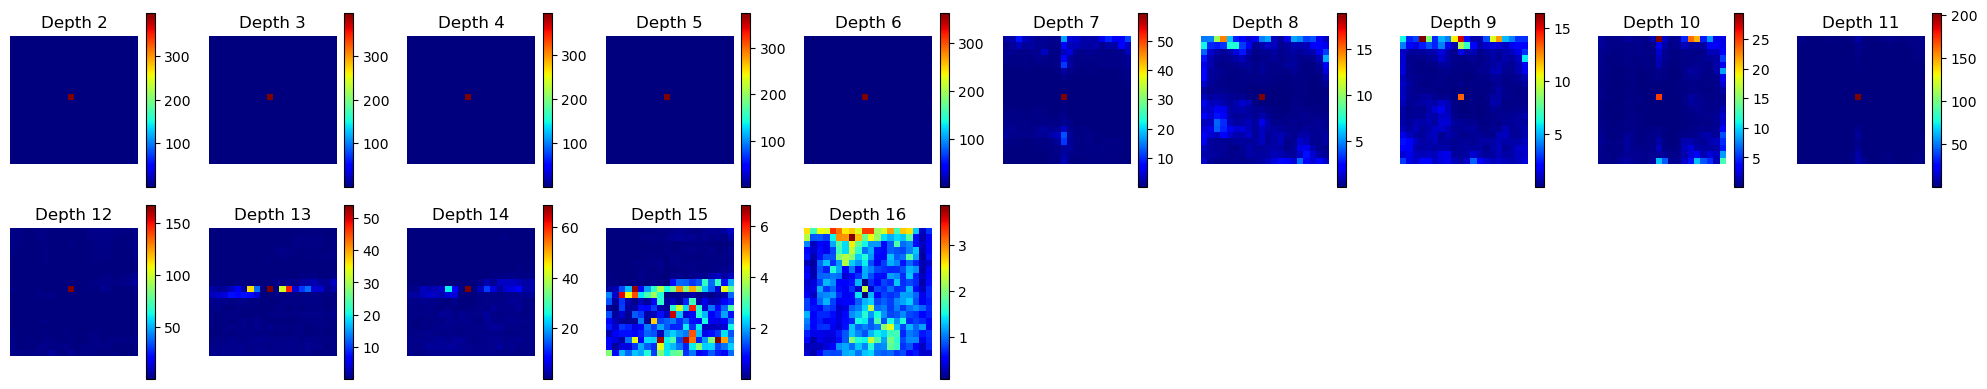

In [ ]:
def plot_psf(path, epoch):

    path = f"{path}/epoch_{epoch:03d}.pt"
    raw = torch.load(path)                 # [D,1,k,k]  (raw parameter; can be negative)
    k = raw.shape[-1]

    vmin, vmax = 0,3.0

    used = torch.nn.functional.softplus(raw)                 # ≥ 0
    used = used / used.sum(dim=(-2, -1), keepdim=True)       # 정규화
    used = used * (k ** 2)                                   # forward와 동일 스케일
    used = torch.flip(used, dims=[-2, -1])                   # conv2d용 flip                # 비음수 확인

    # (선택) ‘물리적 PSF 모양’을 보고 싶다면 flip을 빼고 시각화
    physical = torch.nn.functional.softplus(raw)
    physical = physical / physical.sum(dim=(-2, -1), keepdim=True)
    # physical 은 conv2d flip 전의 모양

    # 플롯(예: used 보여주기)
    psf_stack = used.squeeze(1)  # [D,k,k]
    D = psf_stack.shape[0]
    ncols = 10
    nrows = math.ceil(D / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows), squeeze=False)

    for i in range(D):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        im = ax.imshow(psf_stack[i].cpu().numpy(), cmap='jet')
        fig.colorbar(im, ax=ax)
        ax.set_title(f"Depth {i+2}")  # min_depth=2 기준
        ax.axis('off')

    for i in range(D, nrows*ncols):
        r, c = divmod(i, ncols)
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

plot_psf("/home/yl3836/mono_event/rpg_e2depth/e2depth/0816_on_E300_P20_D15_delta", epoch=10)

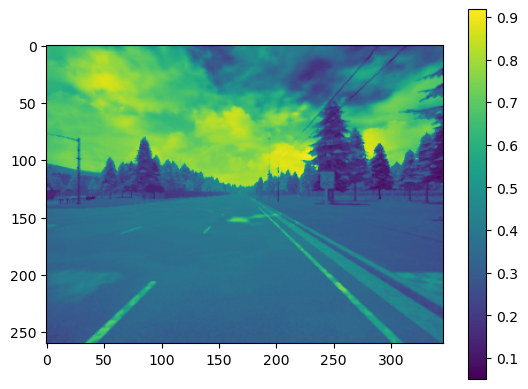

In [87]:
plt.imshow(frames[0].squeeze(0))
plt.colorbar()

In [47]:
def get_psfs(path, epoch):
    empty = []
    path = f"{path}/epoch_{epoch:03d}.pt"
    raw = torch.load(path)                 # [D,1,k,k]  (raw parameter; can be negative)
    k = raw.shape[-1]

    vmin, vmax = 0,3.0

    used = torch.nn.functional.softplus(raw)                 # ≥ 0
    used = used / used.sum(dim=(-2, -1), keepdim=True)       # 정규화
    used = used * (k ** 2)                                   # forward와 동일 스케일
    used = torch.flip(used, dims=[-2, -1])                   # conv2d용 flip                # 비음수 확인

    for i in range(15):
        # 플롯(예: used 보여주기)
        psf_stack = used.squeeze(1)
        empty.append(psf_stack[i])
    empty_stack = torch.stack(empty)
    return empty_stack

In [ ]:
print(get_psfs("/home/yl3836/mono_event/rpg_e2depth/e2depth/0816_on_E300_P20_D15_delta", epoch=10).shape)

torch.Size([15, 20, 20])


In [61]:
psf_test = get_psfs("/home/yl3836/mono_event/rpg_e2depth/e2depth/0816_on_E300_P20_D15_delta", epoch=10)
print(psf_test[d].shape)
print(frames[0].shape)

torch.Size([20, 20])
torch.Size([1, 260, 346])


In [71]:
print(net.psf_layer.psfs.shape)
psf_test = get_psfs("/home/yl3836/mono_event/rpg_e2depth/e2depth/0816_on_E300_P20_D15_delta", epoch=10)
print(psf_test.shape)

torch.Size([15, 1, 20, 20])
torch.Size([15, 20, 20])


In [ ]:
net.forward()

In [83]:
convolved_list = []
psf_test = get_psfs("/home/yl3836/mono_event/rpg_e2depth/e2depth/0816_on_E300_P20_D15_delta", epoch=200)

#psf_test = net.psf_layer.psfs
num_depth = 15
convolved = None
for d in range(num_depth):
    mask = (depth_bins[0] == d+2).float()

    if mask.sum() == 0:
        continue
    filtered = f.conv2d(frames[0], psf_test[d].unsqueeze(0), padding = 'same')

    if convolved is None:
            convolved = torch.zeros_like(filtered)

    convolved = filtered* mask
    convolved_list.append(convolved)
convolved_stack = torch.stack(convolved_list)

print(convolved_stack.shape)

RuntimeError: Expected 3-dimensional input for 3-dimensional weight[1, 20, 20], but got 4-dimensional input of size [1, 1, 260, 346] instead

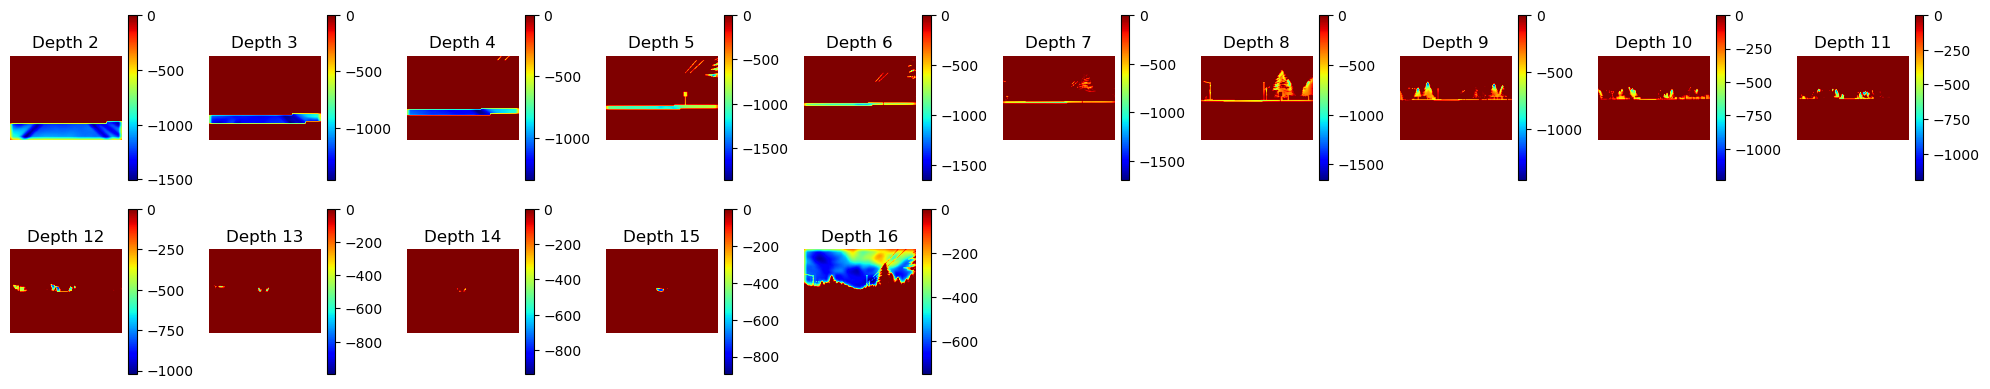

In [84]:
psf_stack = convolved_stack.squeeze(1)  # [D,k,k]
D = psf_stack.shape[0]
ncols = 10
nrows = math.ceil(D / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows), squeeze=False)

for i in range(D):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    im = ax.imshow(psf_stack[i].detach().numpy(), cmap='jet')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"Depth {i+2}")  # min_depth=2 기준
    ax.axis('off')

for i in range(D, nrows*ncols):
    r, c = divmod(i, ncols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2281146/663144307.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


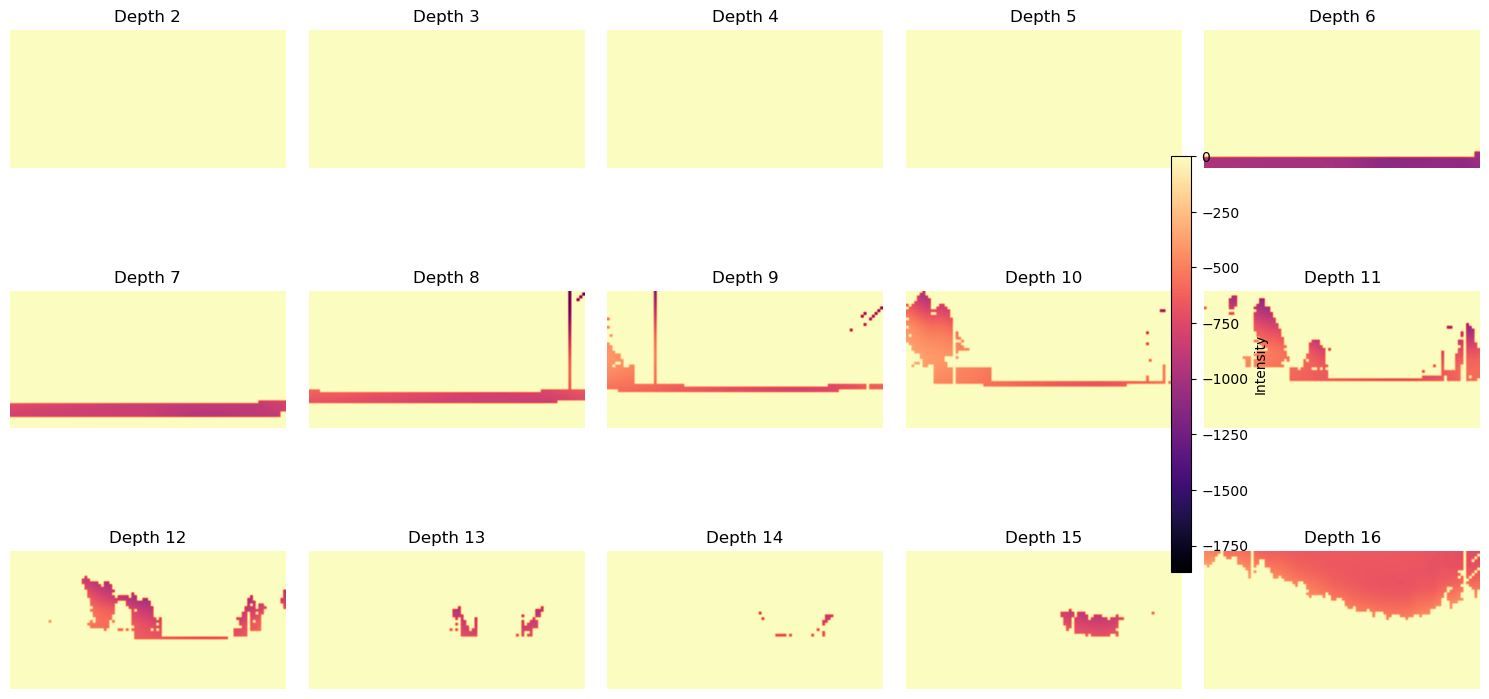

In [85]:
import math
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_convolved_stack(stack, ncols=5, title_prefix="Depth", cmap="magma", share_scale=True):
    """
    stack: [D, 1, H, W] or [D, H, W]
    """
    imgs = stack.squeeze(1) if stack.dim() == 4 else stack  # [D,H,W]
    D, H, W = imgs.shape

    # 공통 색 스케일(권장)
    if share_scale:
        vmin = float(imgs.min())
        vmax = float(imgs.max())
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        norm = None

    nrows = math.ceil(D / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows), squeeze=False)

    for i in range(D):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        arr = imgs[i].detach().cpu().numpy()
        im = ax.imshow(arr[100:150,100:200], cmap=cmap, norm=norm)
        ax.set_title(f"{title_prefix} {i+2}")  # depth_bins가 2부터라면 +2
        ax.axis('off')

    # 남는 칸 제거
    for j in range(D, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis('off')

    if share_scale:
        cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                            ax=axes.ravel().tolist(), shrink=0.6)
        cbar.set_label("Intensity")

    plt.tight_layout()
    plt.show()

# 사용 예시
plot_convolved_stack(convolved_stack, ncols=5, title_prefix="Depth", cmap="magma", share_scale=True)


In [ ]:
%load_ext autoreload
%autoreload 2

PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/model_best.pth.tar'
BASE_FOLDER = '/home/yl3836/DENSE/test_depth_upsampled_input/test_sequence_00_town10/'
USE_GPU = True

args = SimpleNamespace(
    path_to_model=PATH_TO_MODEL,
    base_folder=BASE_FOLDER,
    use_gpu=USE_GPU,
)

In [15]:
print("cuda?", torch.cuda.is_available(), "cuda_ver:", torch.version.cuda)
if torch.cuda.is_available(): print(torch.cuda.get_device_name(0))


cuda? False cuda_ver: 11.3


In [ ]:
    model = load_model(args.path_to_model)
    device = get_device(args.use_gpu)
    model = model.to(device)
    model.eval()

    base_folder = args.base_folder
    event_folder = ""
    depth_folder = 'depths'
    frame_folder = 'frames'

TypeError: load_model() got an unexpected keyword argument 'map_location'

In [2]:
path_to_model = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/model_best.pth.tar'
path_to_test_sequence = '/home/yl3836/DENSE/test_depth_upsampled_input/test_sequence_00_town10/imgs'

In [3]:
model = load_model(path_to_model)


Loading model /home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/model_best.pth.tar...


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [2]:
path = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0816_on_E300_P20_D15_delta/example_psf/checkpoint-epoch300-loss-0.0009.pth.tar'
config = json.load(open('/home/yl3836/mono_event/rpg_e2depth/e2depth/configs/example_psf_config_test_dalta_depth_upsampled.json'))

In [3]:
model = eval(config['arch'])(config['model'])
checkpoint = torch.load(path, map_location='cpu')
model.load_state_dict(checkpoint['state_dict'])

Using UpsampleConvLayer (slow, but no checkerboard artefacts)


<All keys matched successfully>